# Dental X-ray Dataset: Preprocessing (Deduplication + Stratified Split)

`notebooks/01_eda.ipynb` found two problems with the naive merge (which just concatenates
each source dataset's own train/valid/test split):

- **Source imbalance**: the panoramic dataset outnumbers `xray1` ~13:1 in image count, and
  `xray1` contributes **zero** `Crown` labels. Evaluating on the naive merged test split
  mostly measures performance on the panoramic source.
- No deduplication was ever run across the two sources.

This notebook fixes both: it pools every kept image across the naive splits (ignoring
which split it originally came from), drops exact-duplicate images, then reassigns images
to train/valid/test **stratified by source dataset** so every split gets proportional
representation from both.

This does *not* fix the overall `Filling` >> `Cavity`/`Crown` class imbalance (~5:1) —
that's a separate problem, best handled at training time (class-weighted loss /
oversampling), not by splitting differently.

The logic lives in `src/data/split.py`; this notebook calls into it and shows before/after.

## 1. Environment setup

Same bootstrap as `01_eda.ipynb` — detects Colab vs. local and makes `src/` importable.

In [1]:
import subprocess
import sys
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/neuroarcane/dental-cavity-detector.git"
    REPO_ROOT = Path("/content/dental-cavity-detector")
    if not REPO_ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_ROOT)], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO_ROOT), "pull"], check=True)

    from google.colab import drive
    drive.mount("/content/drive")
else:
    def _find_repo_root(start: Path) -> Path:
        for parent in [start, *start.parents]:
            if (parent / "requirements.txt").exists() and (parent / "src").exists():
                return parent
        raise RuntimeError("Could not locate repo root (looked for requirements.txt + src/)")

    REPO_ROOT = _find_repo_root(Path.cwd())

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"IN_COLAB = {IN_COLAB}")
print(f"REPO_ROOT = {REPO_ROOT}")

IN_COLAB = False
REPO_ROOT = /Users/varsha/Documents/dental-cavity-detector


## 2. Imports

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.data.config import DATA_PROCESSED, TARGET_CLASSES
from src.data.prepare_dataset import merge_datasets, print_merge_summary
from src.data.eda import load_annotations, load_image_metadata
from src.data.split import remove_exact_duplicates, stratified_resplit
from src.data.balance import compute_class_instance_counts, oversample_minority_classes

%matplotlib inline
pd.set_option("display.max_columns", None)

## 3. Rebuild the naive merge

Same as `01_eda.ipynb` — rebuilds `data/processed/` from `data/raw/` with each source's
own original train/valid/test split preserved (this is the "before" state we're about to fix).

In [3]:
stats = merge_datasets()
print_merge_summary(stats)

Source A classes kept: {'Cavity': 'Cavity', 'Fillings': 'Filling', 'Impacted Tooth': 'Impacted Tooth'}
Source B classes kept: {'Caries': 'Cavity', 'Crown': 'Crown', 'Filling': 'Filling', 'impacted tooth': 'Impacted Tooth'}

train: seen=10234 kept=10023 dropped(no target-class objects)=211
valid: seen=3086 kept=3044 dropped(no target-class objects)=42
test: seen=1687 kept=1665 dropped(no target-class objects)=22

Instance counts (target classes only):
  Cavity: 11300
  Filling: 54270
  Crown: 11252
  Impacted Tooth: 28406


### Before: source balance per split

This is the problem — `xray1` is barely represented, and unevenly so, across splits.

In [4]:
annotations_before = load_annotations()
images_before = load_image_metadata()
images_before.groupby(["split", "source"]).size().unstack(fill_value=0)

source,panoramic,xray1
split,,
test,1569,96
train,9295,728
valid,2839,205


## 4. Deduplication

Drops exact-duplicate images (by content hash) across all splits, keeping the first
occurrence found.

In [5]:
dedup_stats = remove_exact_duplicates()
print(f"Checked {dedup_stats['checked']} images, removed {len(dedup_stats['removed'])} exact duplicates")
if dedup_stats["removed"]:
    print("Removed:", dedup_stats["removed"][:20], "..." if len(dedup_stats["removed"]) > 20 else "")

Checked 14732 images, removed 57 exact duplicates
Removed: ['panoramic_1162760000-jpg_png_jpg.rf.d45e416d70b335fa30f651b45a7933f3', 'panoramic_2126380000-jpg_png_jpg.rf.b3116ed12b5ecb68b1a39c31464b9542', 'panoramic_2405470000-jpg_png_jpg.rf.a61121ee7e9020775cc819afbe7c84a1', 'panoramic_3008120000-jpg_png_jpg.rf.655d14d2ba7478263fe462b81a479463', 'panoramic_3027370000-jpg_png_jpg.rf.cf9e4358dca5105a86ca8a3e3334c148', 'panoramic_3229280000-jpg_png_jpg.rf.92ab320895bb7a40fb510183c40555db', 'panoramic_3346860000-jpg_png_jpg.rf.613e4fea52b531ab632cee0724ee2900', 'panoramic_3534230000-jpg_png_jpg.rf.b7cca45334e2b4712ff959802cea09cd', 'panoramic_3591920000-jpg_png_jpg.rf.9d6df199c767ceb5ca61b24e12be9dee', 'panoramic_3604640000-jpg_png_jpg.rf.fa0a1978ad519825d94790ea72d75271', 'panoramic_3606690000-jpg_png_jpg.rf.d1e207e7e950cec40c23575f2f222caa', 'panoramic_3657330000-jpg_png_jpg.rf.db7d898289defa894a6cd7838e309782', 'panoramic_3734190000-jpg_png_jpg.rf.b52e12cd713b84340d830c8a60995c59', 'pan

## 5. Stratified re-split

Pools every remaining image (ignoring its current split) and reassigns to train/valid/test
(70/15/15) stratified by source dataset, then moves files between split folders accordingly.

In [6]:
split_stats = stratified_resplit(train_frac=0.7, valid_frac=0.15, test_frac=0.15)
print(f"Total images: {split_stats['total_images']}")
print(f"Moved between splits: {split_stats['moved']}")
print("\nNew split sizes:", split_stats["split_counts"])
print("\nSource counts per new split:")
for split, counts in split_stats["split_source_counts"].items():
    print(f"  {split}: {counts}")

Total images: 14675
Moved between splits: 6940

New split sizes: {'train': 10272, 'valid': 2201, 'test': 2202}

Source counts per new split:
  train: {'panoramic': 9552, 'xray1': 720}
  valid: {'panoramic': 2047, 'xray1': 154}
  test: {'panoramic': 2047, 'xray1': 155}


### After: source balance per split

Each split should now carry a proportional share of both sources.

In [7]:
annotations_after = load_annotations()
images_after = load_image_metadata()
images_after.groupby(["split", "source"]).size().unstack(fill_value=0)

source,panoramic,xray1
split,,
test,2047,155
train,9552,720
valid,2047,154


### After: class balance per split

In [8]:
pd.crosstab(annotations_after["split"], annotations_after["class"])

class,Cavity,Crown,Filling,Impacted Tooth
split,,,,
test,1674,1527,8184,4304
train,7896,7809,37818,19761
valid,1675,1853,8087,4239


### Before vs. after: source proportion per split

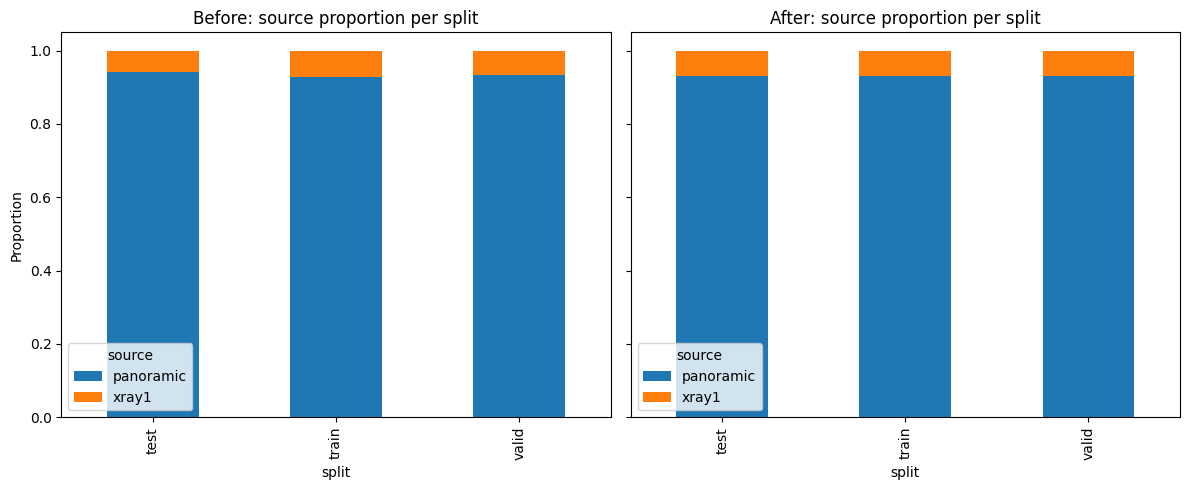

In [9]:
def source_proportions(images_df):
    counts = images_df.groupby(["split", "source"]).size().unstack(fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

source_proportions(images_before).plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Before: source proportion per split")
axes[0].set_ylabel("Proportion")

source_proportions(images_after).plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("After: source proportion per split")

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "preprocessing_source_balance.png")
plt.show()

## 6. Class-imbalance handling (oversampling)

`Filling` outnumbers `Cavity`/`Crown` roughly 5:1. Splitting differently can't fix this
(images carry multiple class instances each), so instead this duplicates **train-split
only** images containing under-represented classes until each class reaches at least
50% of the majority class's instance count (capped at 5 duplicates of any single source
image, so the model doesn't overfit to a handful of repeated images).

`valid`/`test` are never touched by this step — evaluation must reflect the true,
unmodified class distribution, or the metrics stop meaning anything. This must also run
*after* the stratified re-split above, not before, so duplicated images can't end up
shuffled into valid/test.

In [10]:
balance_stats = oversample_minority_classes(split="train", target_ratio=0.5, max_duplicates_per_image=5)
print("Majority class:", balance_stats["majority_class"])
print("\nBefore:", balance_stats["before"])
print("After: ", balance_stats["after"])
print("\nImages duplicated per class:", balance_stats["duplicated_images"])

Majority class: Filling

Before: {'Cavity': 7896, 'Filling': 37818, 'Crown': 7809, 'Impacted Tooth': 19761}
After:  {'Cavity': 21052, 'Filling': 63264, 'Crown': 18912, 'Impacted Tooth': 27237}

Images duplicated per class: {'Cavity': 3171, 'Filling': 0, 'Crown': 2672, 'Impacted Tooth': 0}


### Before vs. after: train class balance

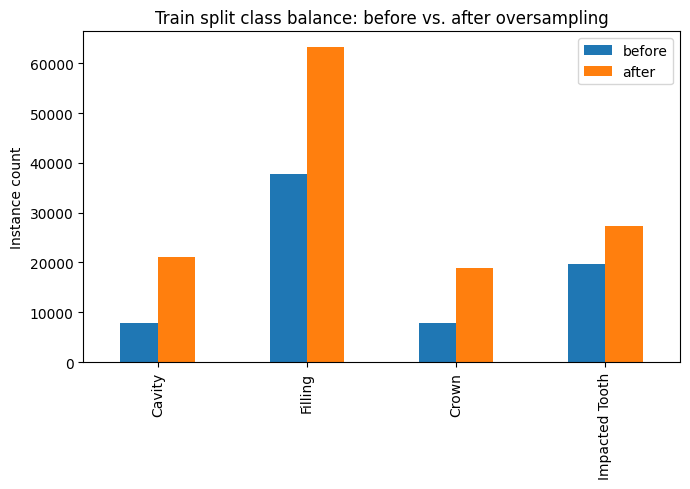

,before,after
Cavity,7896,21052
Filling,37818,63264
Crown,7809,18912
Impacted Tooth,19761,27237


In [11]:
before_after = pd.DataFrame({
    "before": balance_stats["before"],
    "after": balance_stats["after"],
})
before_after.plot(kind="bar", figsize=(7, 5))
plt.title("Train split class balance: before vs. after oversampling")
plt.ylabel("Instance count")
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "preprocessing_class_balance.png")
plt.show()

before_after

### Sanity check: valid/test class counts are unchanged

In [12]:
print("valid:", compute_class_instance_counts(split="valid"))
print("test: ", compute_class_instance_counts(split="test"))

valid: {'Cavity': 1675, 'Filling': 8087, 'Crown': 1853, 'Impacted Tooth': 4239}


test:  {'Cavity': 1674, 'Filling': 8184, 'Crown': 1527, 'Impacted Tooth': 4304}


## 7. Summary

- Removed exact-duplicate images found across the two sources (see count above).
- Re-split train/valid/test (70/15/15) stratified by source dataset, so every split now
  carries a proportional mix of `xray1` and `panoramic` images instead of each split being
  dominated by whichever source happened to assign that image to that split originally.
- Oversampled train-split images containing `Cavity`/`Crown` so each reaches at least 50%
  of `Filling`'s instance count — `valid`/`test` are untouched, so evaluation still
  reflects the true class distribution.
- `data/processed/data.yaml` is unchanged (same 4 classes, same paths).
- **Still not addressed**: resizing/letterboxing to a fixed input size and augmentation —
  both intentionally deferred to the `ultralytics` trainer (`imgsz` + its built-in
  augmentation pipeline) rather than done here. Confirm that's the actual plan with
  whoever owns training setup rather than assuming it. Near-duplicate (not just
  exact-duplicate) detection across sources also isn't implemented.